In [ ]:
import pandas as pd
from pathlib import Path

GRADES =  list(range(1, 5))
TEXTS = ["lobster", "trick", "zoo"]

from src.models.models import ModelInfo
from src.experiment import Experiment
from src.utils.read_datasets import read_datasets
from src.utils.encoders import AudioEncoderType


In [ ]:
df_with_missing_audio = read_datasets(experiment=Experiment(
    ModelInfo(None, None, None, None),
    tuple(TEXTS), test_dataset_names=None,
    audio_encoder_type=AudioEncoderType.whisper60s_mean.value), drop_samples_with_missing_embeddings=False)
df_with_missing_audio

In [ ]:
df_with_audio = read_datasets(experiment=Experiment(
    ModelInfo(None, None, None, None),
    tuple(TEXTS), test_dataset_names=None,
    audio_encoder_type=AudioEncoderType.whisper60s_mean.value))
df_with_audio

In [4]:
import re
class IDNormalizer:
    def __init__(self) -> None:
        self.regex_pattern = re.compile(r'(?<=[^0-9])0+')
        self.known_prefixes = set()
        self.normalized_count = 0
    
    def normalize_id(self, _id):
        #exclude russir - it is 0n in our and osf
        #exclude ds - it is 0n in our and missing in osf
        if _id.startswith("russir") or _id.startswith("ds"):
            return _id
        
        result = re.sub(self.regex_pattern, '', _id)
        if result != _id:
            self.normalized_count += 1
            self.known_prefixes.add("".join(c for c in _id if not c.isdigit()))
            # print(f"Normalized id: {_id} -> {result}")
        return result



def compare_with_osf(_df):
    osf_dataset = pd.read_csv("./data/testing/data_car.tsv", sep="\t")
    osf_size = osf_dataset.shape[0]

    raw_osf_ids = osf_dataset["ID"].unique().tolist()
    raw_our_ids = _df["ID"].unique().tolist()
    normalizer = IDNormalizer()
    osf_ids = set([normalizer.normalize_id(id) for id in raw_osf_ids])
    print(f"Normalized count osf: {normalizer.normalized_count}")
    normalizer.normalized_count = 0
    our_ids = set([normalizer.normalize_id(id) for id in raw_our_ids])
    print(f"Normalized count our: {normalizer.normalized_count}")
    print(f"Known prefixes for normalized ids: {normalizer.known_prefixes}")

    assert len(osf_ids) == len(raw_osf_ids), f"Expected osf_ids size {len(raw_osf_ids)}, got {len(osf_ids)}"
    our_norm_vs_raw = set(our_ids).symmetric_difference(set(raw_our_ids))
    assert len(our_norm_vs_raw) == 0, f"Expected no difference between normalized and raw our_ids, got {our_norm_vs_raw}"

    osf_only = osf_ids - our_ids
    our_only = our_ids - osf_ids
    common = osf_ids.intersection(our_ids)

    print(f"osf_only: {osf_only}")
    print(f"our_only: {our_only}")
    print(f"common: {common}")
    print()
    print(f"osf dataset size: {osf_size}")
    print(f"our dataset size: {len(our_ids)}")
    print(f"osf_only count: {len(osf_only)}")
    print(f"our_only count: {len(our_only)}")
    print(f"common count: {len(common)}")
    print(f"size-only = size-only:", len(osf_ids) - len(osf_only) == len(our_ids) - len(our_only) == len(common))

    

In [ ]:
from itertools import combinations

for k, dataset in {"original_with_missing_audio": df_with_missing_audio, "final_with_audio": df_with_audio}.items():
    print(f"Dataset: {k}")
    compare_with_osf(dataset)

    print()
    # participant cooccurrence stats for each text
    print("Unique IDs count:", dataset["ID"].nunique())
    print("Audio files count:", dataset["ID"].size)
    print()
    print("Gender distribution:")
    print(dataset["gender"].value_counts())
    print()
    print("Original label 1 distribution:")
    print(dataset["orig_label1"].value_counts().sort_index(ascending=False))

    
    print("IDs per task:")
    tasks = {}
    for task in dataset["task"].unique():
        ids = set(dataset[dataset["task"] == task]["ID"])
        tasks[task] = ids
        print(f"{task}: {len(ids)} unique IDs")

    print("\nCommon IDs between tasks:")
    for comb_len in range(2, len(dataset["task"].unique()) + 1):
        for task_comb in combinations(dataset["task"].unique(), comb_len):
            common_ids = set.intersection(*(tasks[task] for task in task_comb))
            print(f"{' & '.join(task_comb)}: {len(common_ids)} common IDs")
            
    print("=" * 40)
    print("=" * 40)
    print("\n")
    print("\n")

Dataset: original_with_missing_audio


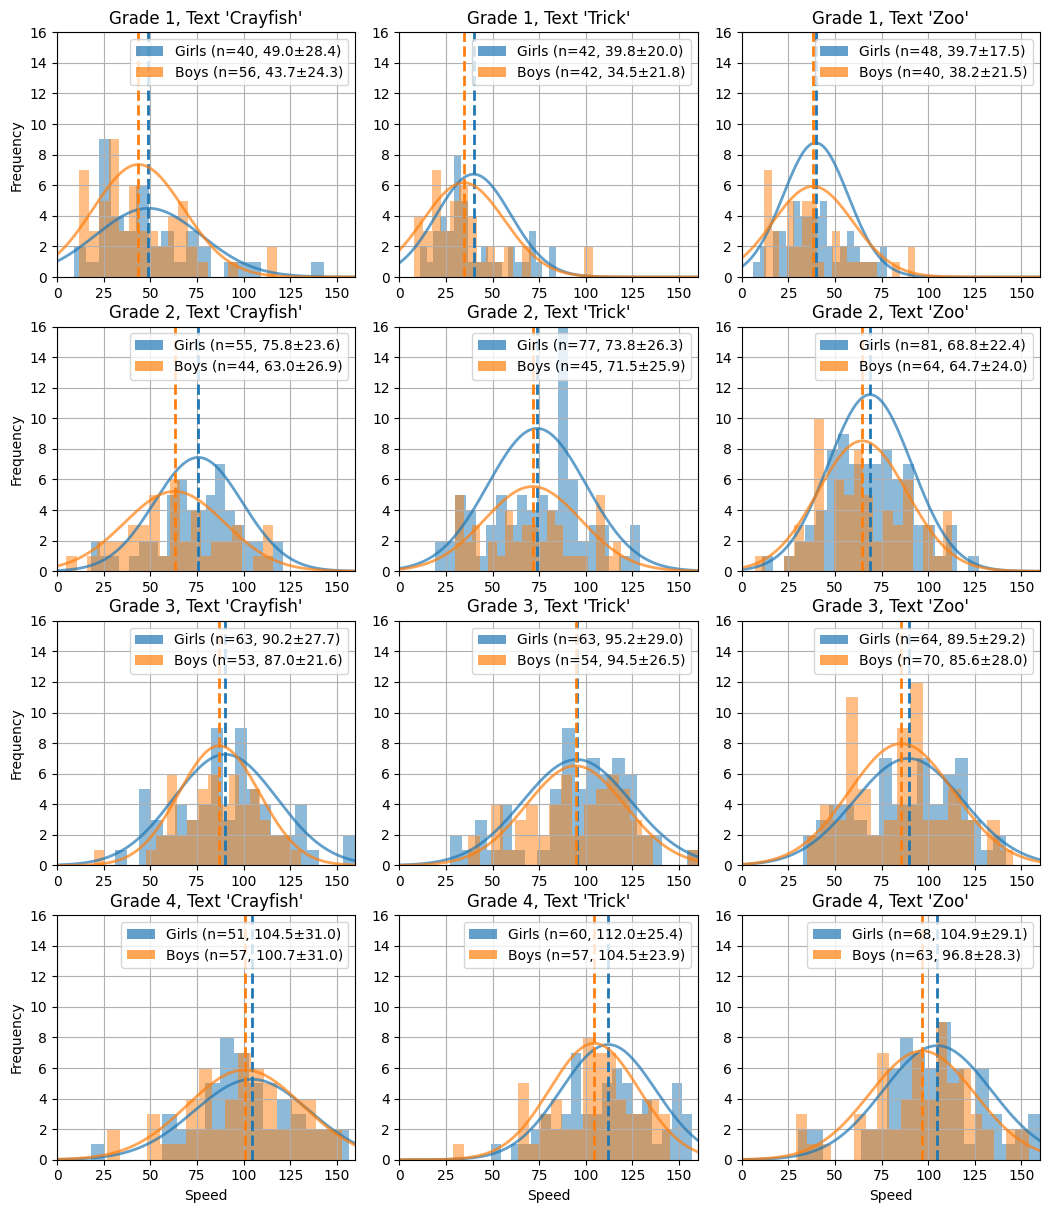

Dataset: final_with_audio


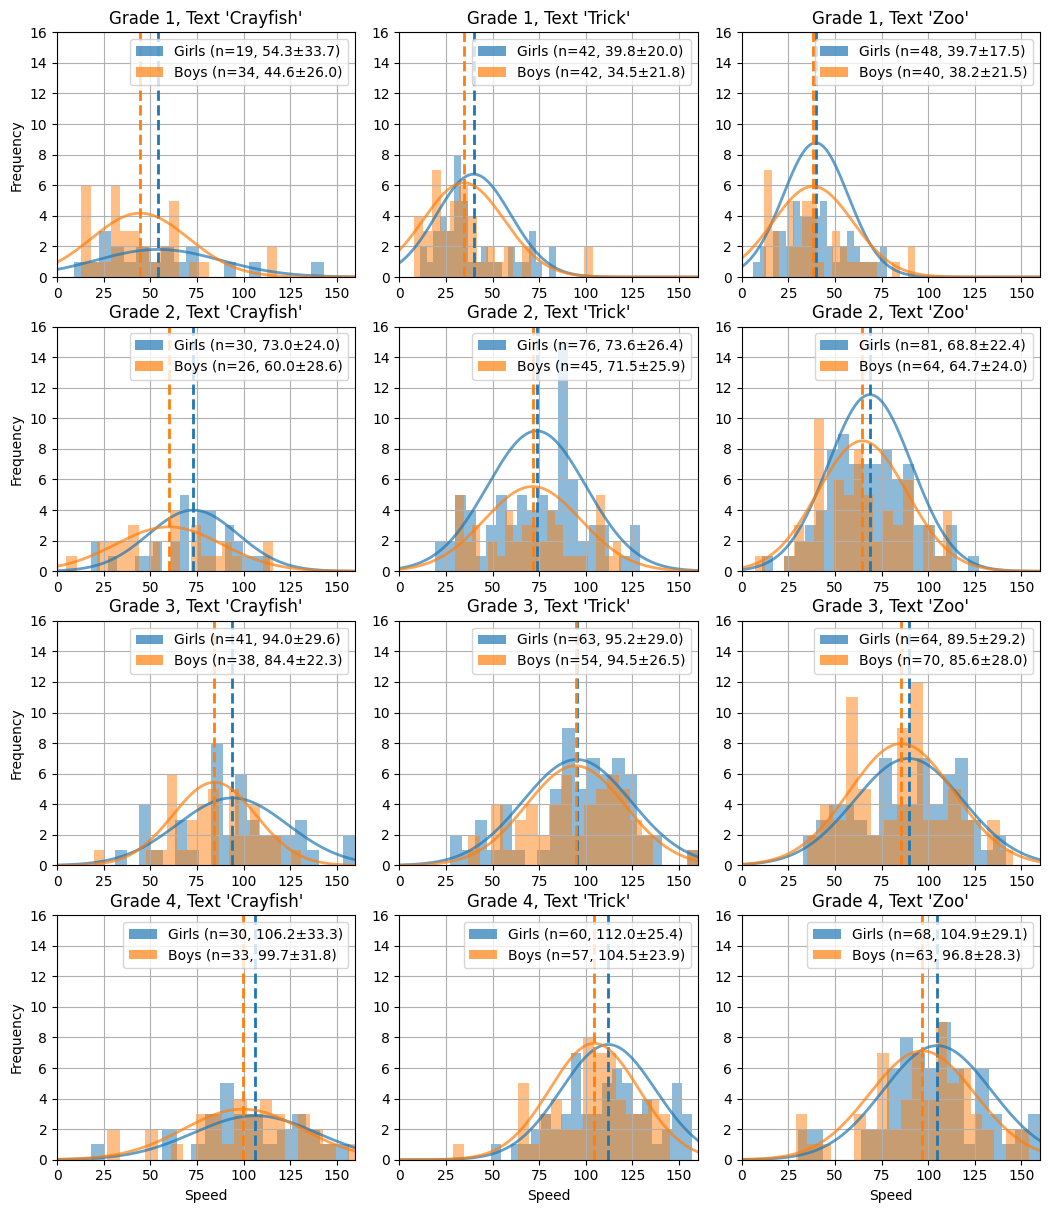

In [ ]:
# plot distributions of speeds for each strata grade-task-gender on single figure with subplots
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from scipy.stats import norm

for k, dataset in {"original_with_missing_audio": df_with_missing_audio, "final_with_audio": df_with_audio}.items():
    print(f"Dataset: {k}")
    # create subplots

    grades = sorted(dataset["grade"].unique())
    tasks = sorted(dataset["task"].unique())
    genders = sorted(dataset["gender"].unique())

    fig, axes = plt.subplots(nrows=len(grades), ncols=len(tasks), figsize=(14*0.75, 16*0.75))
    axes = axes.flatten()
    for grade in grades:
        for task in tasks:
            # show both genders on the same subplot using different colors
            ax = axes[grades.index(grade) * len(tasks) + tasks.index(task)]
            task_grade_subset = dataset[(dataset["grade"] == grade) & (dataset["task"] == task)]
            girls_count = task_grade_subset[task_grade_subset["gender"] == 0.0].shape[0]
            boys_count = task_grade_subset[task_grade_subset["gender"] == 1.0].shape[0]
            
            legend_elements = []
            colors = {0.0: 'C0', 1.0: 'C1'}  # Map gender to matplotlib default colors

            MAX_X = 160
            N_BINS = 20
            
            for gender in genders:
                # add vline on mean speed for this strata
                subset = task_grade_subset[(task_grade_subset["gender"] == gender)]
                if len(subset) > 0:
                    color = colors[gender]
                    mean_speed = subset["speed"].mean()
                    std_speed = subset["speed"].std()
                    
                    ax.hist(subset["speed"], bins=N_BINS, alpha=0.5, color=color)
                    ax.axvline(mean_speed, color=color, linestyle='--', linewidth=2)  # Mean line
                    
                    # Plot curve
                    x = np.linspace(0, MAX_X, 200)
                    gaussian = norm.pdf(x, mean_speed, std_speed) * len(subset) * (MAX_X / N_BINS)  # Scale to match histogram
                    ax.plot(x, gaussian, color=color, linewidth=2, alpha=0.7)
                    
                    
                    # Legend entry for histogram bins
                    gender_name = "Girls" if gender == 0.0 else "Boys"
                    count = girls_count if gender == 0.0 else boys_count
                    legend_elements.append(
                        Patch(facecolor=color, alpha=0.7, label=f'{gender_name} (n={count}, {mean_speed:.1f}±{std_speed:.1f})')
                    )
                    
            task_name = ("crayfish" if task == "lobster" else task).capitalize()
            ax.set_title(f"Grade {grade}, Text '{task_name}'")
            
            if grade == grades[-1]:
                ax.set_xlabel("Speed")
            if task == tasks[0]:
                ax.set_ylabel("Frequency")

            ax.legend(handles=legend_elements, loc='upper right')
            ax.set_xlim(0, MAX_X)
            ax.set_ylim(0, 16)
            ax.grid()

    fig.tight_layout(pad=0.25)
    plt.show()